# 🔥 Step 1.1: Collect All Images & Masks from Subfolders (Fast CPU Processing)

In [ ]:
import os
import shutil
import glob

# Define dataset paths
dataset_groups = {
    "ElbowKnee_Anterior": {
        "images": r"C:\SIUE\Fall 24\539\EnhancedImages\ElbowKnee\Anterior\Cancer",
        "masks": r"C:\SIUE\Fall 24\539\EnhancedImages\ElbowKnee\Anterior\Cancer\Masks",
        "non_cancer_images": r"C:\SIUE\Fall 24\539\EnhancedImages\ElbowKnee\Anterior\NoCancer",
        "non_cancer_masks": r"C:\SIUE\Fall 24\539\EnhancedImages\ElbowKnee\Anterior\NoCancer\Masks"
    },
    "ElbowKnee_Lateral": {
        "images": r"C:\SIUE\Fall 24\539\EnhancedImages\ElbowKnee\Lateral\Cancer",
        "masks": r"C:\SIUE\Fall 24\539\EnhancedImages\ElbowKnee\Lateral\Cancer\Masks",
        "non_cancer_images": r"C:\SIUE\Fall 24\539\EnhancedImages\ElbowKnee\Lateral\NoCancer",
        "non_cancer_masks": r"C:\SIUE\Fall 24\539\EnhancedImages\ElbowKnee\Lateral\NoCancer\Masks"
    },
    "Wrist_Lateral": {
        "images": r"C:\SIUE\Fall 24\539\EnhancedImages\Wrist\Lateral\Cancer",
        "masks": r"C:\SIUE\Fall 24\539\EnhancedImages\Wrist\Lateral\Cancer\Masks",
        "non_cancer_images": r"C:\SIUE\Fall 24\539\EnhancedImages\Wrist\Lateral\NoCancer",
        "non_cancer_masks": r"C:\SIUE\Fall 24\539\EnhancedImages\Wrist\Lateral\NoCancer\Masks"
    }
}

# Define final dataset paths (ensure correct class-wise structure)
processed_dataset_path = r"C:\SIUE\Fall 24\539\ProcessedDataset"

image_class_dirs = {
    "cancer": os.path.join(processed_dataset_path, "images", "cancer"),
    "no_cancer": os.path.join(processed_dataset_path, "images", "no_cancer")
}

mask_class_dirs = {
    "cancer": os.path.join(processed_dataset_path, "masks", "cancer"),
    "no_cancer": os.path.join(processed_dataset_path, "masks", "no_cancer")
}

# Ensure directories exist
for path in image_class_dirs.values():
    os.makedirs(path, exist_ok=True)
for path in mask_class_dirs.values():
    os.makedirs(path, exist_ok=True)

# Move images & masks into class-based folders (Ensuring all images are collected)
def gather_all_images():
    total_cancer, total_no_cancer = 0, 0  # Track number of images

    for group, paths in dataset_groups.items():
        for label, (image_folder, mask_folder) in {
            "cancer": (paths["images"], paths["masks"]),
            "no_cancer": (paths["non_cancer_images"], paths["non_cancer_masks"])
        }.items():
            image_files = glob.glob(os.path.join(image_folder, "*.tif"))

            for img_path in image_files:
                mask_path = os.path.join(mask_folder, os.path.basename(img_path))
                if not os.path.exists(mask_path):
                    continue  # Skip if the corresponding mask is missing

                # Copy images & masks into their correct class folders
                shutil.copy(img_path, os.path.join(image_class_dirs[label], os.path.basename(img_path)))
                shutil.copy(mask_path, os.path.join(mask_class_dirs[label], os.path.basename(mask_path)))

                if label == "cancer":
                    total_cancer += 1
                else:
                    total_no_cancer += 1

    print(f"✅ Gathered {total_cancer} Cancer Images & {total_no_cancer} No-Cancer Images.")

# Run gathering process
gather_all_images()


✅ Gathered 35 Cancer Images & 21 No-Cancer Images.


In [ ]:
!nvidia-smi

Tue Feb 18 15:03:28 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 561.09                 Driver Version: 561.09         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| 30%   34C    P8             13W /  220W |    1940MiB /  12282MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import os
import glob

# Set device to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define GPU-compatible augmentations
image_transforms = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

mask_transforms = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Function to apply the same augmentation to an image & mask on GPU
def augment_image_mask(image, mask):
    seed = torch.randint(0, 99999, (1,)).item()  # Set a random seed

    torch.manual_seed(seed)  # Apply same seed for image
    image = image_transforms(image).to(device)

    torch.manual_seed(seed)  # Apply same seed for mask
    mask = mask_transforms(mask).to(device)

    return image, mask

# Function to augment and save images/masks by class
def augment_class_images(class_name, num_augments=10):
    image_dir = image_class_dirs[class_name]
    mask_dir = mask_class_dirs[class_name]

    image_files = glob.glob(os.path.join(image_dir, "*.tif"))

    for img_path in image_files:
        mask_path = os.path.join(mask_dir, os.path.basename(img_path))
        if not os.path.exists(mask_path):
            continue  # Skip if the corresponding mask is missing

        # Load images & masks as PIL images
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # Save the original image and mask
        original_image_path = img_path.replace(".tif", ".jpg")
        original_mask_path = mask_path.replace(".tif", ".jpg")

        image.save(original_image_path)
        mask.save(original_mask_path)

        print(f"Saved original: {original_image_path}")  # Debugging

        # Generate augmented versions
        for i in range(num_augments):
            aug_img, aug_mask = augment_image_mask(image, mask)  # Apply same transformation to both

            # Convert back to PIL for saving
            aug_img = transforms.ToPILImage()(aug_img.cpu())
            aug_mask = transforms.ToPILImage()(aug_mask.cpu())

            # Save augmented images & masks
            aug_img_path = os.path.join(image_dir, f"{os.path.basename(img_path).split('.')[0]}_aug{i}.jpg")
            aug_mask_path = os.path.join(mask_dir, f"{os.path.basename(mask_path).split('.')[0]}_aug{i}.jpg")

            aug_img.save(aug_img_path)
            aug_mask.save(aug_mask_path)

            print(f"Saved augmented: {aug_img_path}")  # Debugging

# Apply augmentations for both classes
augment_class_images("cancer", num_augments=10)
augment_class_images("no_cancer", num_augments=10)

print("✅ Step 1.2 Complete: Verified GPU-Accelerated Augmentation with Saved Images")

Saved original: C:\SIUE\Fall 24\539\ProcessedDataset\images\cancer\anddol022312ahr2-orig.jpg
Saved augmented: C:\SIUE\Fall 24\539\ProcessedDataset\images\cancer\anddol022312ahr2-orig_aug0.jpg
Saved augmented: C:\SIUE\Fall 24\539\ProcessedDataset\images\cancer\anddol022312ahr2-orig_aug1.jpg
Saved augmented: C:\SIUE\Fall 24\539\ProcessedDataset\images\cancer\anddol022312ahr2-orig_aug2.jpg
Saved augmented: C:\SIUE\Fall 24\539\ProcessedDataset\images\cancer\anddol022312ahr2-orig_aug3.jpg
Saved augmented: C:\SIUE\Fall 24\539\ProcessedDataset\images\cancer\anddol022312ahr2-orig_aug4.jpg
Saved augmented: C:\SIUE\Fall 24\539\ProcessedDataset\images\cancer\anddol022312ahr2-orig_aug5.jpg
Saved augmented: C:\SIUE\Fall 24\539\ProcessedDataset\images\cancer\anddol022312ahr2-orig_aug6.jpg
Saved augmented: C:\SIUE\Fall 24\539\ProcessedDataset\images\cancer\anddol022312ahr2-orig_aug7.jpg
Saved augmented: C:\SIUE\Fall 24\539\ProcessedDataset\images\cancer\anddol022312ahr2-orig_aug8.jpg
Saved augmented:

# Dataset Splitting Script

In [ ]:
import os
import glob
import shutil
import random

# Define dataset directories
base_path = r"C:\SIUE\Fall 24\539\ProcessedDataset"
image_dirs = {
    "cancer": os.path.join(base_path, "images", "cancer"),
    "no_cancer": os.path.join(base_path, "images", "no_cancer")
}
mask_dirs = {
    "cancer": os.path.join(base_path, "masks", "cancer"),
    "no_cancer": os.path.join(base_path, "masks", "no_cancer")
}

# Output directories
split_paths = {
    "train": os.path.join(base_path, "train"),
    "val": os.path.join(base_path, "val"),
    "test": os.path.join(base_path, "test"),
}

# Ensure output directories exist
for split in split_paths.values():
    os.makedirs(os.path.join(split, "images", "cancer"), exist_ok=True)
    os.makedirs(os.path.join(split, "images", "no_cancer"), exist_ok=True)
    os.makedirs(os.path.join(split, "masks", "cancer"), exist_ok=True)
    os.makedirs(os.path.join(split, "masks", "no_cancer"), exist_ok=True)

# Define split ratios
train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15

# Function to split and move images/masks
def split_dataset(class_name):
    image_files = glob.glob(os.path.join(image_dirs[class_name], "*.jpg"))  # Use augmented set
    random.shuffle(image_files)  # Shuffle to avoid bias

    total = len(image_files)
    train_count = int(total * train_ratio)
    val_count = int(total * val_ratio)

    # Splitting images and masks while keeping pairs together
    splits = {
        "train": image_files[:train_count],
        "val": image_files[train_count:train_count + val_count],
        "test": image_files[train_count + val_count:]
    }

    for split, files in splits.items():
        for img_path in files:
            mask_path = os.path.join(mask_dirs[class_name], os.path.basename(img_path))  # Get corresponding mask
            if os.path.exists(mask_path):
                # Move image
                shutil.copy(img_path, os.path.join(split_paths[split], "images", class_name, os.path.basename(img_path)))
                # Move mask
                shutil.copy(mask_path, os.path.join(split_paths[split], "masks", class_name, os.path.basename(mask_path)))

    print(f"✅ {class_name} Split - Train: {train_count}, Val: {val_count}, Test: {len(splits['test'])}")

# Apply split for both classes
split_dataset("cancer")
split_dataset("no_cancer")

print("✅ Step 1: Dataset Split Complete - Ready for Feature Extraction")


✅ cancer Split - Train: 269, Val: 57, Test: 59
✅ no_cancer Split - Train: 161, Val: 34, Test: 36
✅ Step 1: Dataset Split Complete - Ready for Feature Extraction


In [ ]:
!pip install mahotas


   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   -- ------------------------------------- 0.1/1.7 MB 2.0 MB/s eta 0:00:01
   -------- ------------------------------- 0.4/1.7 MB 3.4 MB/s eta 0:00:01
   -------------------- ------------------- 0.9/1.7 MB 6.1 MB/s eta 0:00:01
   --------------------------------- ------ 1.4/1.7 MB 7.6 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 7.4 MB/s eta 0:00:00


# Deep Feature Extraction (ResNet50 + ViT)

In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

# Load pre-trained models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load ResNet50
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1).to(device)
resnet = torch.nn.Sequential(*(list(resnet.children())[:-1]))  # Remove last layer
resnet.eval()

# Load Vision Transformer (ViT)
vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1).to(device)
vit.eval()  # Keep full ViT model

# Define image transformation
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ViT & ResNet input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Function to extract deep features
def extract_deep_features(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        # Extract ResNet50 features
        resnet_features = resnet(image).flatten().cpu().numpy()

        # Extract ViT features (ensure correct indexing)
        vit_output = vit(image)  # Forward pass
        if len(vit_output.shape) == 2:
            vit_features = vit_output.cpu().numpy().flatten()  # Directly flatten if 2D
        else:
            vit_features = vit_output[:, 0, :].cpu().numpy().flatten()  # Extract CLS token if 3D

    return np.concatenate((resnet_features, vit_features))  # Combine both feature sets

print("✅ Fixed ViT Feature Extraction - Now Run Feature Extraction")


✅ Fixed ViT Feature Extraction - Now Run Feature Extraction


In [ ]:
import os
import glob
import cv2
import pandas as pd
import numpy as np
from skimage.feature import graycomatrix, graycoprops

# Define feature save path
feature_save_path = r"C:\SIUE\Fall 24\539\Feature"
os.makedirs(feature_save_path, exist_ok=True)

# Function to compute GLCM texture features
def compute_texture_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    return [
        graycoprops(glcm, 'contrast')[0, 0],
        graycoprops(glcm, 'energy')[0, 0],
        graycoprops(glcm, 'homogeneity')[0, 0]
    ]

# Function to compute basic statistical features
def compute_statistical_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    return [np.mean(gray), np.var(gray)]

# Function to extract all features (Deep + Handcrafted)
def extract_hybrid_features(image_path):
    image = cv2.imread(image_path)
    deep_features = extract_deep_features(image_path)
    texture_features = compute_texture_features(image)
    statistical_features = compute_statistical_features(image)

    return np.concatenate((deep_features, texture_features, statistical_features))

# Extract features and save to CSV
feature_data = []
labels = []
image_paths = []

for class_name in ["cancer", "no_cancer"]:
    img_dir = os.path.join(r"C:\SIUE\Fall 24\539\ProcessedDataset\train\images", class_name)

    for img_path in glob.glob(os.path.join(img_dir, "*.jpg")):
        features = extract_hybrid_features(img_path)
        feature_data.append(features)
        labels.append(1 if class_name == "cancer" else 0)
        image_paths.append(img_path)

# Convert to DataFrame
feature_df = pd.DataFrame(feature_data)
feature_df["label"] = labels
feature_df["image_path"] = image_paths  # Save paths for reference

# Save extracted features
feature_csv_path = os.path.join(feature_save_path, "train_features_hybrid.csv")
feature_df.to_csv(feature_csv_path, index=False)

print(f"✅ Feature Extraction Complete - Features saved at: {feature_csv_path}")


✅ Feature Extraction Complete - Features saved at: C:\SIUE\Fall 24\539\Feature\train_features_hybrid.csv


In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd
import os

# Define paths
feature_save_path = r"C:\SIUE\Fall 24\539\Feature"
feature_csv_path = os.path.join(feature_save_path, "train_features_hybrid.csv")

# Load extracted features
feature_df = pd.read_csv(feature_csv_path)

# Separate features and labels
X = feature_df.drop(columns=["label", "image_path"]).values  # Drop label & image path
y = feature_df["label"].values

# Apply SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Convert back to DataFrame
balanced_feature_df = pd.DataFrame(X_resampled)
balanced_feature_df["label"] = y_resampled

# Save the balanced dataset
balanced_feature_csv_path = os.path.join(feature_save_path, "train_features_balanced_hybrid.csv")
balanced_feature_df.to_csv(balanced_feature_csv_path, index=False)

print(f"✅ SMOTE Balancing Complete - Balanced Features saved at: {balanced_feature_csv_path}")


✅ SMOTE Balancing Complete - Balanced Features saved at: C:\SIUE\Fall 24\539\Feature\train_features_balanced_hybrid.csv


Epoch 1/20 | Train Loss: 1.0004, Train Acc: 56.25% | Val Loss: 0.8930, Val Acc: 43.57%
Epoch 2/20 | Train Loss: 0.6655, Train Acc: 62.14% | Val Loss: 0.7773, Val Acc: 62.86%
Epoch 3/20 | Train Loss: 0.6230, Train Acc: 68.75% | Val Loss: 0.6259, Val Acc: 71.43%
Epoch 4/20 | Train Loss: 0.5445, Train Acc: 73.75% | Val Loss: 0.6510, Val Acc: 63.57%
Epoch 5/20 | Train Loss: 0.4801, Train Acc: 78.75% | Val Loss: 0.6072, Val Acc: 72.86%
Epoch 6/20 | Train Loss: 0.4617, Train Acc: 80.18% | Val Loss: 0.5217, Val Acc: 75.00%
Epoch 7/20 | Train Loss: 0.4076, Train Acc: 84.64% | Val Loss: 0.5960, Val Acc: 71.43%
Epoch 8/20 | Train Loss: 0.3854, Train Acc: 86.61% | Val Loss: 0.4143, Val Acc: 77.86%
Epoch 9/20 | Train Loss: 0.3169, Train Acc: 88.75% | Val Loss: 0.4317, Val Acc: 81.43%
Epoch 10/20 | Train Loss: 0.2814, Train Acc: 91.61% | Val Loss: 0.3783, Val Acc: 80.71%
Epoch 11/20 | Train Loss: 0.3423, Train Acc: 86.25% | Val Loss: 0.4585, Val Acc: 79.29%
Epoch 12/20 | Train Loss: 0.3745, Train A

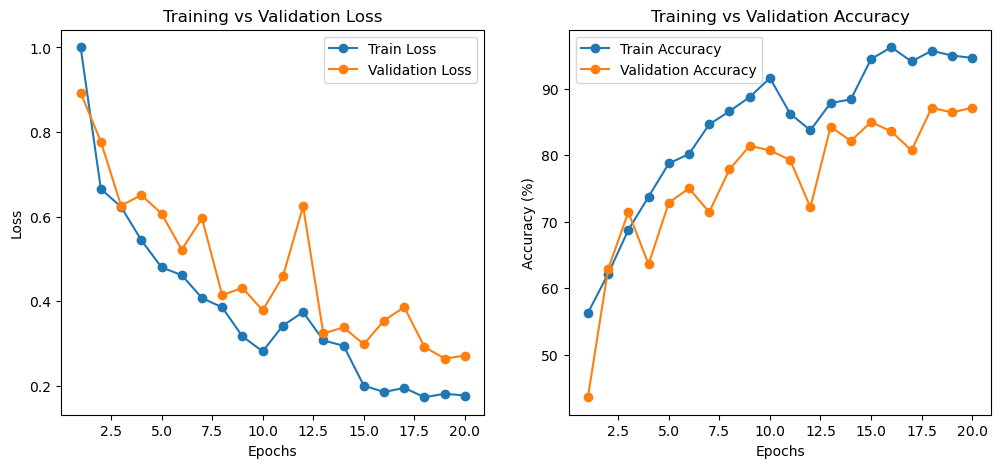

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

# Load extracted hybrid features
feature_save_path = r"C:\SIUE\Fall 24\539\Feature"
balanced_feature_csv_path = os.path.join(feature_save_path, "train_features_balanced_hybrid.csv")

feature_df = pd.read_csv(balanced_feature_csv_path)
X = torch.tensor(feature_df.drop(columns=["label"]).values, dtype=torch.float32)
y = torch.tensor(feature_df["label"].values, dtype=torch.long)

# Split into training (80%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch datasets
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

# Define DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Load pre-trained ViT Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1).to(device)

# Modify ViT classifier to match extracted feature dimensions
input_dim = X.shape[1]  # Number of extracted features
vit.heads = nn.Sequential(
    nn.Linear(input_dim, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 2)  # 2 classes (cancer, no cancer)
).to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vit.heads.parameters(), lr=1e-4)

# Store loss and accuracy for graphing
num_epochs = 20
train_losses, val_losses = [], []
train_accs, val_accs = [], []

# Training loop
for epoch in range(num_epochs):
    vit.train()
    train_loss, correct_train, total_train = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()

        outputs = vit.heads(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == y_batch).sum().item()
        total_train += y_batch.size(0)

    train_losses.append(train_loss / len(train_loader))
    train_accs.append(correct_train / total_train * 100)

    # Validation step
    vit.eval()
    val_loss, correct_val, total_val = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = vit.heads(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == y_batch).sum().item()
            total_val += y_batch.size(0)

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(correct_val / total_val * 100)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.2f}% | "
          f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accs[-1]:.2f}%")

# Save trained model
model_save_path = r"C:\SIUE\Fall 24\539\Model"
os.makedirs(model_save_path, exist_ok=True)
torch.save(vit.state_dict(), os.path.join(model_save_path, "vit_feature_classifier.pth"))

print(f"✅ Training Complete - Model saved at: {model_save_path}")

# Plot loss & accuracy
plt.figure(figsize=(12, 5))

# Loss graph
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label="Train Loss", marker="o")
plt.plot(range(1, num_epochs + 1), val_losses, label="Validation Loss", marker="o")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Accuracy graph
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accs, label="Train Accuracy", marker="o")
plt.plot(range(1, num_epochs + 1), val_accs, label="Validation Accuracy", marker="o")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()


In [ ]:
import os
import glob
import cv2
import pandas as pd
import numpy as np
from skimage.feature import graycomatrix, graycoprops
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image

# Define paths
feature_save_path = r"C:\SIUE\Fall 24\539\Feature"
os.makedirs(feature_save_path, exist_ok=True)

test_img_path = r"C:\SIUE\Fall 24\539\ProcessedDataset\test\images"

# Function to compute GLCM texture features
def compute_texture_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    return [
        graycoprops(glcm, 'contrast')[0, 0],
        graycoprops(glcm, 'energy')[0, 0],
        graycoprops(glcm, 'homogeneity')[0, 0]
    ]

# Function to compute basic statistical features
def compute_statistical_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    return [np.mean(gray), np.var(gray)]

# Load pretrained models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1).to(device)
resnet = torch.nn.Sequential(*(list(resnet.children())[:-1]))  # Remove last layer
resnet.eval()

vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1).to(device)
vit.eval()

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Function to extract deep features
def extract_deep_features(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        # Extract ResNet50 features
        resnet_features = resnet(image).flatten().cpu().numpy()

        # Extract ViT features
        vit_output = vit(image)

        # Ensure correct indexing based on tensor shape
        if len(vit_output.shape) == 2:
            vit_features = vit_output.cpu().numpy().flatten()  # Directly flatten if 2D
        else:
            vit_features = vit_output[:, 0, :].cpu().numpy().flatten()  # Extract CLS token if 3D

    return np.concatenate((resnet_features, vit_features))

# Extract test features
test_feature_data = []
test_labels = []
test_image_paths = []

for class_name in ["cancer", "no_cancer"]:
    img_dir = os.path.join(test_img_path, class_name)

    for img_path in glob.glob(os.path.join(img_dir, "*.jpg")):
        features = extract_deep_features(img_path)
        texture_features = compute_texture_features(cv2.imread(img_path))
        statistical_features = compute_statistical_features(cv2.imread(img_path))

        test_feature_data.append(np.concatenate((features, texture_features, statistical_features)))
        test_labels.append(1 if class_name == "cancer" else 0)
        test_image_paths.append(img_path)

# Convert to DataFrame
test_feature_df = pd.DataFrame(test_feature_data)
test_feature_df["label"] = test_labels
test_feature_df["image_path"] = test_image_paths

# Save test features
test_csv_path = os.path.join(feature_save_path, "test_features_hybrid.csv")
test_feature_df.to_csv(test_csv_path, index=False)

print(f"✅ Test Features Extracted & Saved at: {test_csv_path}")


✅ Test Features Extracted & Saved at: C:\SIUE\Fall 24\539\Feature\test_features_hybrid.csv


In [ ]:
import torch
import torchvision.models as models

# Load the trained ViT model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1).to(device)

# Get the correct input size for the classifier
trained_model_feature_size = 3053  # Use the size from the saved model (3053)

# Modify the classifier to match trained model
vit.heads = torch.nn.Sequential(
    torch.nn.Linear(trained_model_feature_size, 512),
    torch.nn.ReLU(),
    torch.nn.Linear(512, 256),
    torch.nn.ReLU(),
    torch.nn.Linear(256, 2)  # Binary classification
).to(device)

# Load the saved model weights correctly
model_save_path = r"C:\SIUE\Fall 24\539\Model\vit_feature_classifier.pth"
vit.load_state_dict(torch.load(model_save_path, map_location=device), strict=False)

vit.eval()

print("✅ ViT Model Successfully Loaded for Testing!")


C:\Users\sami3\AppData\Local\Temp\ipykernel_33356\4224615555.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vit.load_state_dict(torch.load(model_save_path, map_locatio

✅ ViT Model Successfully Loaded for Testing!


C:\Users\sami3\AppData\Local\Temp\ipykernel_33356\1103775599.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vit.load_state_dict(torch.load(model_save_path, map_locatio


🔹 **Classification Report:**
              precision    recall  f1-score   support

   No Cancer       0.94      0.96      0.95        68
      Cancer       0.97      0.96      0.97       105

    accuracy                           0.96       173
   macro avg       0.96      0.96      0.96       173
weighted avg       0.96      0.96      0.96       173



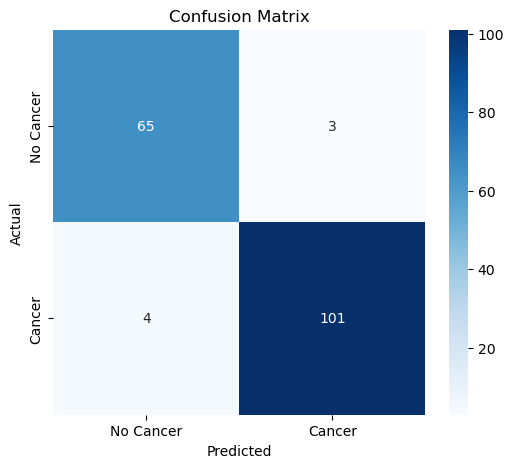

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import pandas as pd
import os

# Load the trained ViT model
model_save_path = r"C:\SIUE\Fall 24\539\Model\vit_feature_classifier.pth"
vit.load_state_dict(torch.load(model_save_path, map_location=device))
vit.to(device)
vit.eval()

# Load test features
test_csv_path = os.path.join(r"C:\SIUE\Fall 24\539\Feature", "test_features_hybrid.csv")
test_df = pd.read_csv(test_csv_path)

# Extract test data
X_test = torch.tensor(test_df.drop(columns=["label", "image_path"]).values, dtype=torch.float32).to(device)
y_test = test_df["label"].values

# Make predictions
with torch.no_grad():
    outputs = vit.heads(X_test)
    _, y_pred = torch.max(outputs, 1)

# Generate classification report
print("\n🔹 **Classification Report:**")
print(classification_report(y_test, y_pred.cpu().numpy(), target_names=["No Cancer", "Cancer"]))

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred.cpu().numpy())

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Cancer", "Cancer"], yticklabels=["No Cancer", "Cancer"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
